# DEGs UpSet Plots

with [new reference genome](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/) AND prefiltering genes with inconsistent counts

# Phase 2 vs. Phase 2
using results from [deseq_p2.v.p2.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_p2.v.p2.ipynb) to look for DEGs that are shared/unique among the comparisons

## 0. load libraries

In [17]:
library(ggvenn)
library(tidyverse)
library(UpSetR)
library(patchwork)
library(rtracklayer)
library(RColorBrewer)

## 1. read CSVs

In [18]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq',
    pattern = '\\.csv$',
    full.names = TRUE
    )

head(files)

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bb_cc.csv"
[2] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_bb.csv"
[3] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_cc.csv"
[4] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_hc.csv"
[5] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_wc.csv"
[6] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bh_ch.csv"

In [19]:
names(files) <- tools::file_path_sans_ext(basename(files))
file_list <- lapply(files, read.csv)
names(file_list)

[1] "bb_cc"        "bc_bb"        "bc_cc"        "bc_hc"        "bc_wc"       
 [6] "bh_ch"        "bh_hh"        "bw_cw"        "bw_ww"        "cb_bb"       
[11] "cb_bc"        "cb_cc"        "cb_ch"        "cb_cw"        "ch_cc"       
[16] "ch_hc"        "cw_cc"        "cw_ch"        "cw_wc"        "hb_bb"       
[21] "hb_bh"        "hb_cb"        "hc_cc"        "hc_hh"        "hh_cc"       
[26] "hh_ch"        "vst_filtered" "wb_bb"        "wb_bw"        "wb_cb"       
[31] "wc_cc"        "wc_hc"        "wc_ww"        "wh_hw"        "ww_cc"       
[36] "ww_cw"

In [20]:
# remove vst_filtered df from list
file_list$vst_filtered <- NULL

In [21]:
head(file_list$bb_cc)

,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.032996495,0.09949223,0.4061655,0.8859809,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.007669405,0.14514609,0.5347197,0.9243933,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.008266903,0.14878180,0.4963221,0.9135582,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.003718678,0.09623197,0.9279458,0.9944321,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.004058318,0.09267542,0.9274474,0.9944321,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.007347953,0.10830123,0.7834673,0.9747439,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


### pull out DEGs

In [22]:
deg_list <- lapply(file_list, function(df) {
    df %>% dplyr::filter(abs(log2FoldChange) >= "1" & padj <= 0.05)
})

names(deg_list)
head(deg_list$bb_cc)

[1] "bb_cc" "bc_bb" "bc_cc" "bc_hc" "bc_wc" "bh_ch" "bh_hh" "bw_cw" "bw_ww"
[10] "cb_bb" "cb_bc" "cb_cc" "cb_ch" "cb_cw" "ch_cc" "ch_hc" "cw_cc" "cw_ch"
[19] "cw_wc" "hb_bb" "hb_bh" "hb_cb" "hc_cc" "hc_hh" "hh_cc" "hh_ch" "wb_bb"
[28] "wb_bw" "wb_cb" "wc_cc" "wc_hc" "wc_ww" "wh_hw" "ww_cc" "ww_cw"

,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111117765,942.73601,1.001590,0.6889971,5.392183e-05,0.028510854,1023.6592469,720.88783,989.94709,147.82547,⋯,1365.142373,942.689103,351.822346,780.422419,620.3467554,614.83157,1449.05621,604.66720,374.101226,543.306393
2,LOC111104782,61.05694,1.290308,1.1196421,8.391552e-05,0.036625806,72.7138026,104.27307,69.35330,44.61005,⋯,38.880637,31.858644,91.672020,8.076817,182.0179103,26.54713,58.79226,36.47901,33.614893,8.539197
3,LOC111105268,368.33858,-1.461112,2.0234094,1.038922e-04,0.040035492,0.9443351,1838.81542,20.90099,55.98124,⋯,17.280283,203.405188,349.344724,42.403288,363.1071577,93.44590,334.30891,1959.91765,640.851665,53.369980
4,LOC144625945,140.12400,2.158239,0.6332465,1.636808e-06,0.002325905,419.2847838,94.24681,152.95728,124.20838,⋯,101.521664,403.542822,14.865733,183.747581,216.3784341,218.74837,140.64030,174.65707,135.543922,148.368543
5,LOC111101301,1022.03779,-6.310740,3.7449050,3.591307e-06,0.004297471,0.9443351,62.16279,0.00000,0.00000,⋯,1.080018,8.985771,0.000000,1.009602,0.9286628,3857.82920,57.63947,28.74104,2.168703,22.415391
6,LOC111101184,51.17287,1.502293,1.5341097,9.716278e-05,0.038087809,84.9901589,20.05251,23.75113,86.59598,⋯,35.640584,17.971543,9.910489,102.979414,21.3592446,35.04221,54.18110,19.89764,22.771379,6.404398


### import GFF file
using [`rtracklayer`](https://bioconductor.org/packages/3.22/bioc/html/rtracklayer.html)

In [23]:
gff.file <- import('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/genome/GCF_053477285.1_ASM5347728v1_genomic.gff') %>%
as.data.frame() %>%
select(description, gene, gene_biotype) %>%
na.omit()

head(gff.file)

,description,gene,gene_biotype
,<chr>,<chr>,<chr>
2,protein O-mannosyl-transferase TMTC2-like,LOC144621260,protein_coding
28,uncharacterized LOC144621269,LOC144621269,protein_coding
63,mitochondrial amidoxime-reducing component 1-like,LOC111120925,protein_coding
79,transfer RNA glutamic acid (anticodon CUC),Trnae-cuc,tRNA
82,transfer RNA glutamic acid (anticodon CUC),Trnae-cuc,tRNA
85,transfer RNA glutamic acid (anticodon CUC),Trnae-cuc,tRNA


## 2. Exploratory Plots

### total DEGs
look at total number of DEGs and up- and down-regulated DEGs for each pairwise comparison

In [24]:
deg_summary <- data.frame(
  dataset = names(deg_list),
  total_genes = sapply(deg_list, nrow),
  upregulated = sapply(deg_list, function(df) sum(df$log2FoldChange > 0)),
  downregulated = sapply(deg_list, function(df) sum(df$log2FoldChange < 0))
)

deg_summary

,dataset,total_genes,upregulated,downregulated
,<chr>,<int>,<int>,<int>
bb_cc,bb_cc,43,29,14
bc_bb,bc_bb,97,18,79
bc_cc,bc_cc,32,7,25
bc_hc,bc_hc,26,8,18
bc_wc,bc_wc,58,13,45
bh_ch,bh_ch,154,52,102
bh_hh,bh_hh,103,53,50
bw_cw,bw_cw,40,13,27
bw_ww,bw_ww,41,14,27


the up and down regulated aren't really that helpful bc it's in relation to the pair, so the only ones that are truly up or down regulated in a way that makes sense easily are the comparisons with CC

In [25]:
# reorder the rows from most DEGs to lease
deg_summary$dataset <- forcats::fct_reorder(deg_summary$dataset, deg_summary$total_genes, .fun = sum)

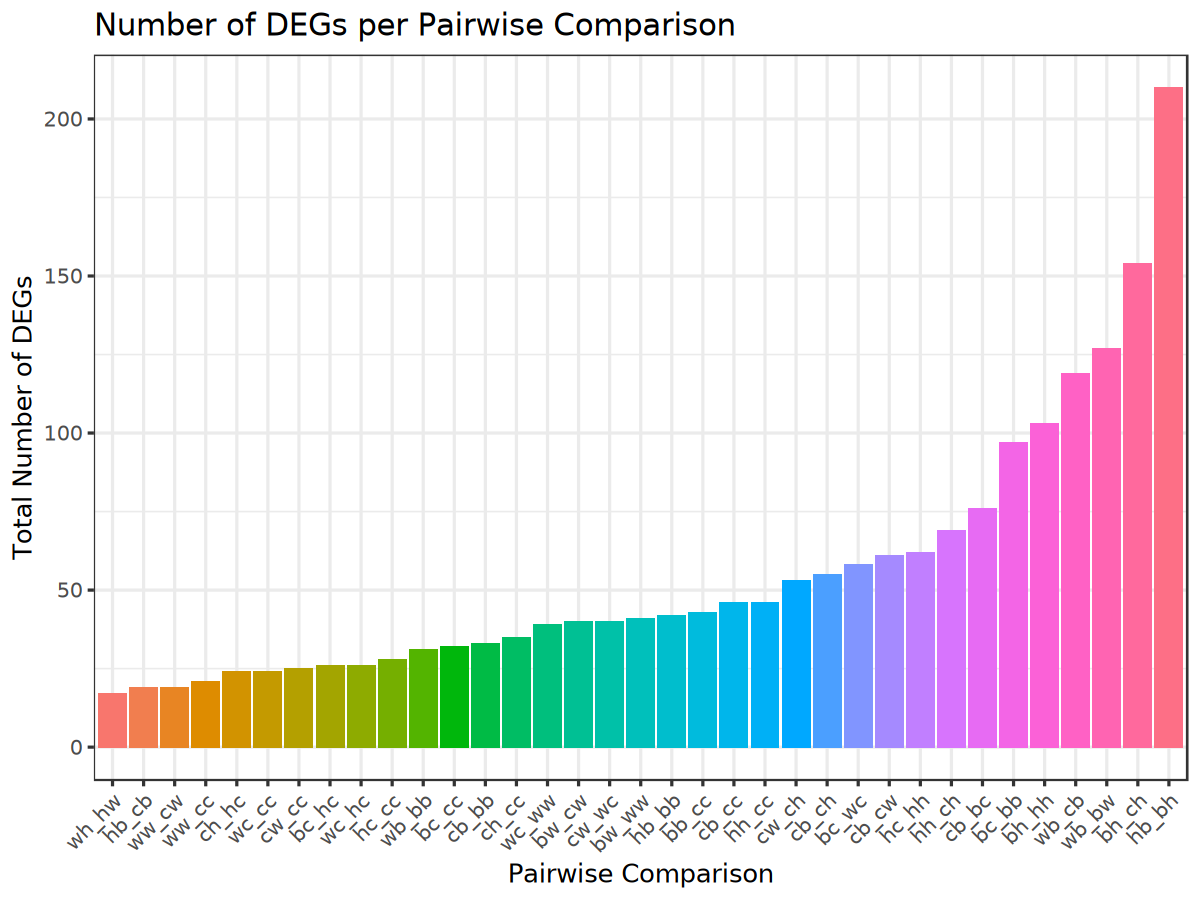

In [26]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

ggplot(deg_summary, aes(x = dataset, y = total_genes, fill = dataset)) +
geom_bar(stat = 'identity') +
guides(fill = 'none') +
theme_bw(base_size = 15) +
labs(title = 'Number of DEGs per Pairwise Comparison', 
    y = 'Total Number of DEGs',
    x = 'Pairwise Comparison') +
theme(axis.text.x = element_text(angle = 45, hjust = 1))

the least amount of DEGs between a pair (and therefore are more similar to each other):
- **WH vs. HW**: timing of single stress doesn't matter? or order doesn't matter?
- **HB vs. CB**: experience the same most recent exposure (both), small CE from early exposure to hypoxia but the majority of the transcriptional profile is due to the most recent exposure

the most amount of DEGs between a pair (and therefore are more different to each other):
- **HB vs. BH**: each exhbited a single and multiple stressor exposure but at different times - emphasizes the importance of timing? or just that warming overpowers hypoxia differently depending on time of exposure?
- **BH vs. CH**: priming with multi stressor vs no stressor when the later stress is hypoxia alone - priming doesn't help here? or maybe multiple stressors early on is really detrimental/causes a lot of shifts?

### CC comparison DEGs

In [27]:
cc_deg <- deg_summary %>%
  filter(grepl("cc", dataset)) %>%
  pivot_longer(
    cols = c(upregulated, downregulated),
    names_to = "direction",
    values_to = "dir_degs"
  )

head(cc_deg)

dataset,total_genes,direction,dir_degs
<fct>,<int>,<chr>,<int>
bb_cc,43,upregulated,29
bb_cc,43,downregulated,14
bc_cc,32,upregulated,7
bc_cc,32,downregulated,25
cb_cc,46,upregulated,23
cb_cc,46,downregulated,23


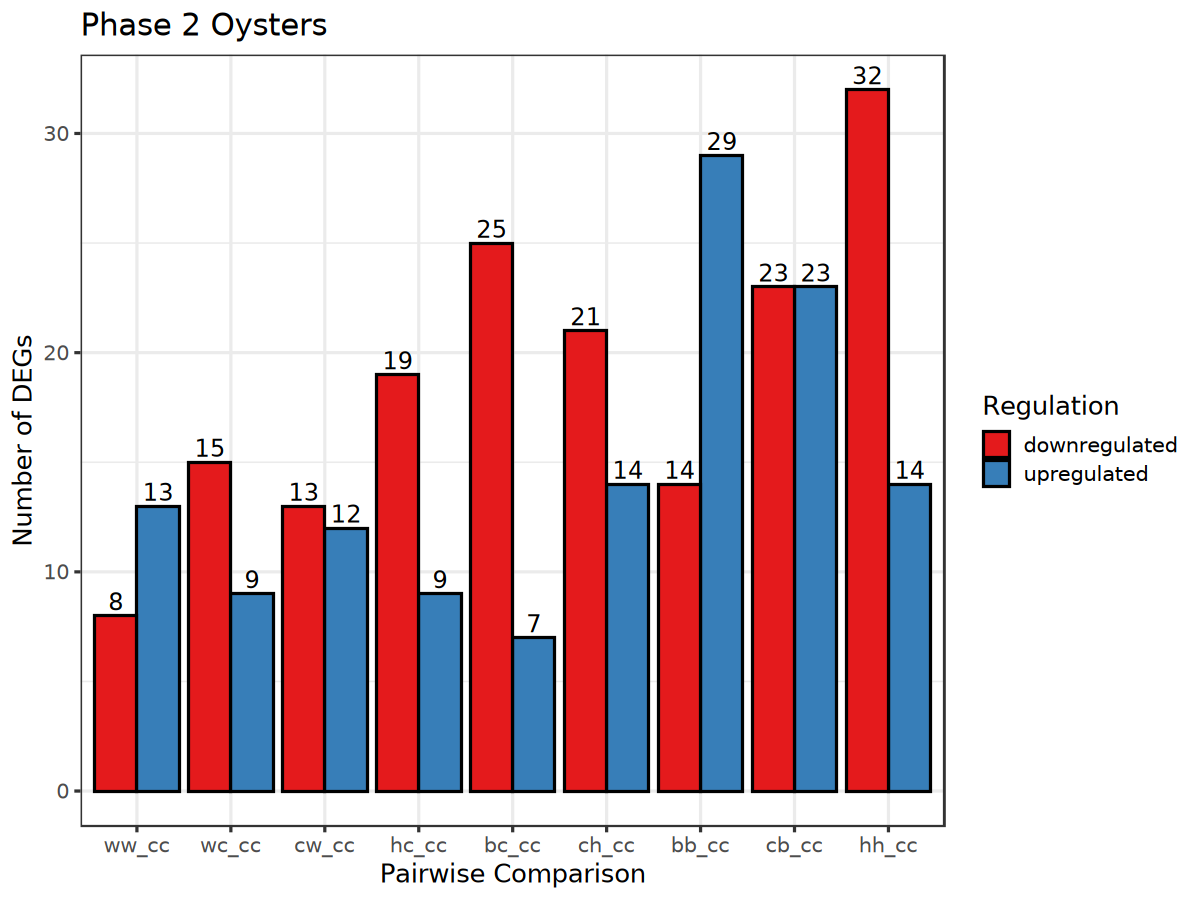

In [28]:
ggplot(cc_deg, aes(x = dataset, y = dir_degs, fill = direction)) +
geom_bar(stat = 'identity', position = 'dodge', col = 'black') +
  geom_text(
    aes(label = dir_degs),
    position = position_dodge(width = 0.9),
    vjust = -0.3,
    size = 5
  ) +
scale_fill_brewer(palette = 'Set1') +
theme_bw(base_size = 15) +
labs(title = 'Phase 2 Oysters',
     x = 'Pairwise Comparison',
     y = 'Number of DEGs',
    fill = 'Regulation')

let's split this up to be more legible:

In [29]:
cc_deg2 <- cc_deg %>%
separate(dataset,
           into = c("comp1", "comp2"),
           sep = "_",
           fill = "left",
          remove = FALSE) %>%
mutate(comp_group = case_when(
    substr(comp1, 1, 1) == 'c' ~ 'single late exposure',
    substr(comp1, 2, 2) == 'c' ~ 'single early exposure',
    TRUE ~ 'repeated exposure'))

head(cc_deg2)

dataset,comp1,comp2,total_genes,direction,dir_degs,comp_group
<fct>,<chr>,<chr>,<int>,<chr>,<int>,<chr>
bb_cc,bb,cc,43,upregulated,29,repeated exposure
bb_cc,bb,cc,43,downregulated,14,repeated exposure
bc_cc,bc,cc,32,upregulated,7,single early exposure
bc_cc,bc,cc,32,downregulated,25,single early exposure
cb_cc,cb,cc,46,upregulated,23,single late exposure
cb_cc,cb,cc,46,downregulated,23,single late exposure


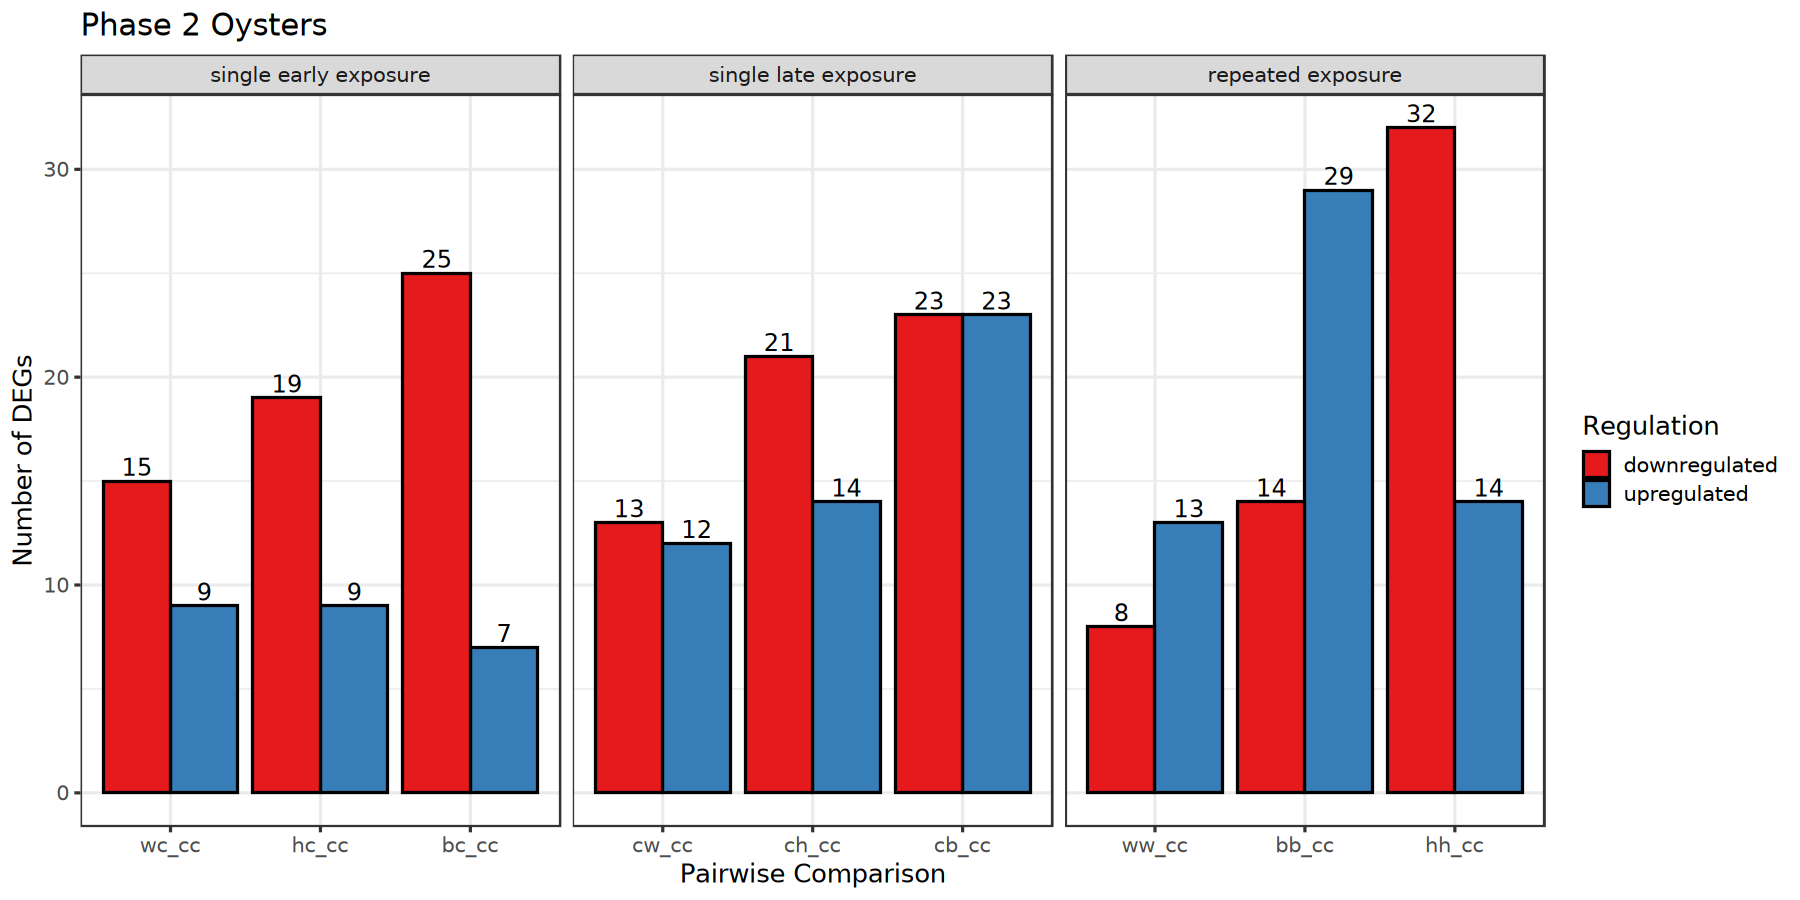

In [68]:
options(repr.plot.width = 15, repr.plot.height = 7.5)

# set order of comparison group
cc_deg2$comp_group <- factor(
  cc_deg2$comp_group,
  levels = c(
    "single early exposure",
    "single late exposure",
    "repeated exposure"
  )
)

ggplot(cc_deg2, aes(x = dataset, y = dir_degs, fill = direction)) +
geom_bar(stat = 'identity', position = 'dodge', col = 'black') +
  geom_text(
    aes(label = dir_degs),
    position = position_dodge(width = 0.9),
    vjust = -0.3,
    size = 5
  ) +
facet_wrap(~comp_group, scales = 'free_x') +
scale_fill_brewer(palette = 'Set1') +
theme_bw(base_size = 15) +
labs(title = 'Phase 2 Oysters',
     x = 'Pairwise Comparison',
     y = 'Number of DEGs',
    fill = 'Regulation')

it's interesting that most DEGs are downregulated (but you see this pattern switch in CW, CB, WW, and BB, where the majority of the DEGs are upregulated)

## 3. UpSet plots *within* comparison groups

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

### 1. Effect of single exposure after period of recovery

In [31]:
# make list of dfs
comp1 = list(WC_v_CC = deg_list$wc_cc$Gene,
         HC_v_CC = deg_list$hc_cc$Gene,
         BC_v_CC = deg_list$bc_cc$Gene)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”


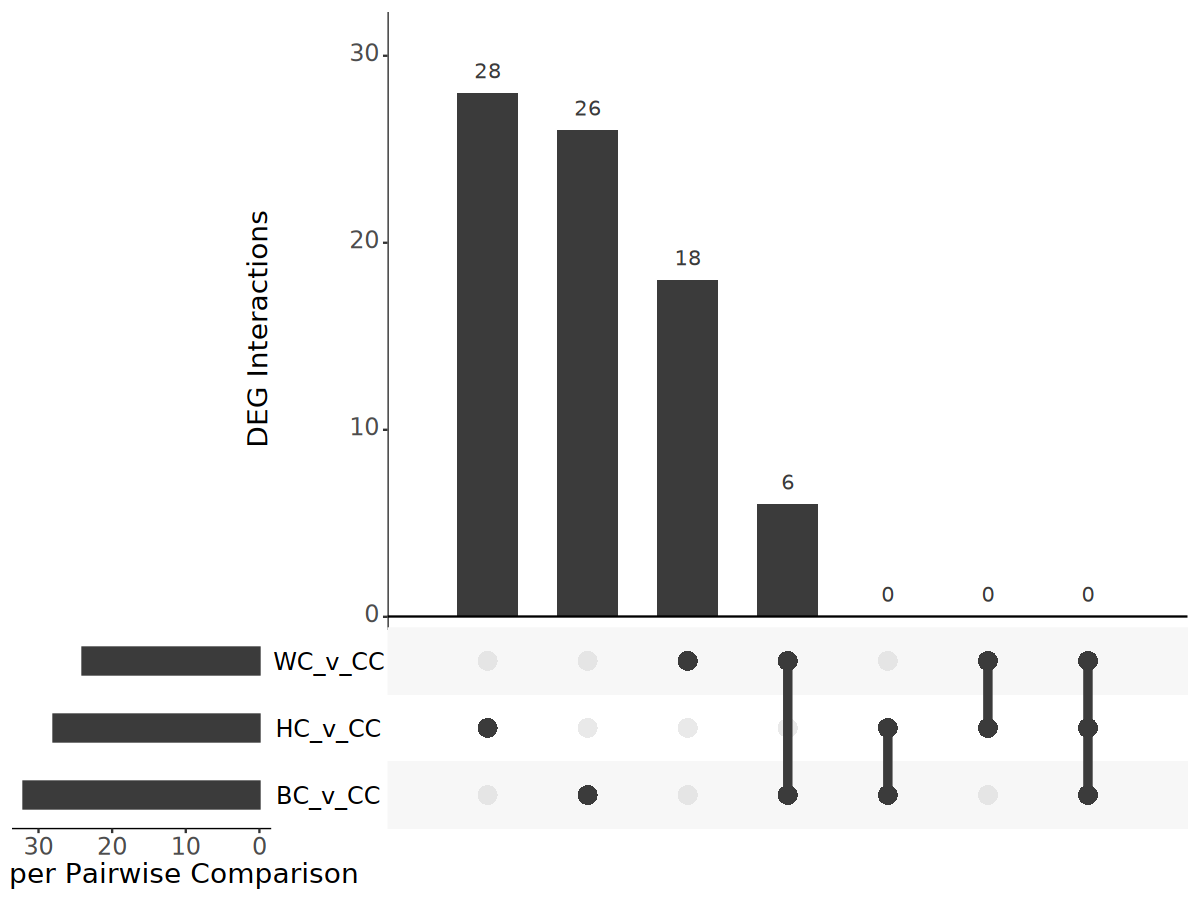

In [32]:
comp1.upset <- UpSetR::upset(
  fromList(comp1),
  nsets = 3,
  order.by = "freq",
  point.size = 5,
  line.size = 2,
  mainbar.y.label = "DEG Interactions",
  sets.x.label = "DEGs per Pairwise Comparison",
  text.scale = c(2, 2, 2, 2, 2, 2),
    empty.intersections = 'on'
)

comp1.upset

Majority of DEGs are not shared between these comparisons, but we do see that 28 genes are shared in all three - general stress response (to early stress) genes? 

same patterns remain as old genome, just reduced numbers

no shared genes across all comparisons!

### 2. Effect of single late exposure

In [33]:
# make list of dfs
comp2 = list(CW_v_CC = deg_list$cw_cc$Gene,
         CH_v_CC = deg_list$ch_cc$Gene,
         CB_v_CC = deg_list$cb_cc$Gene)

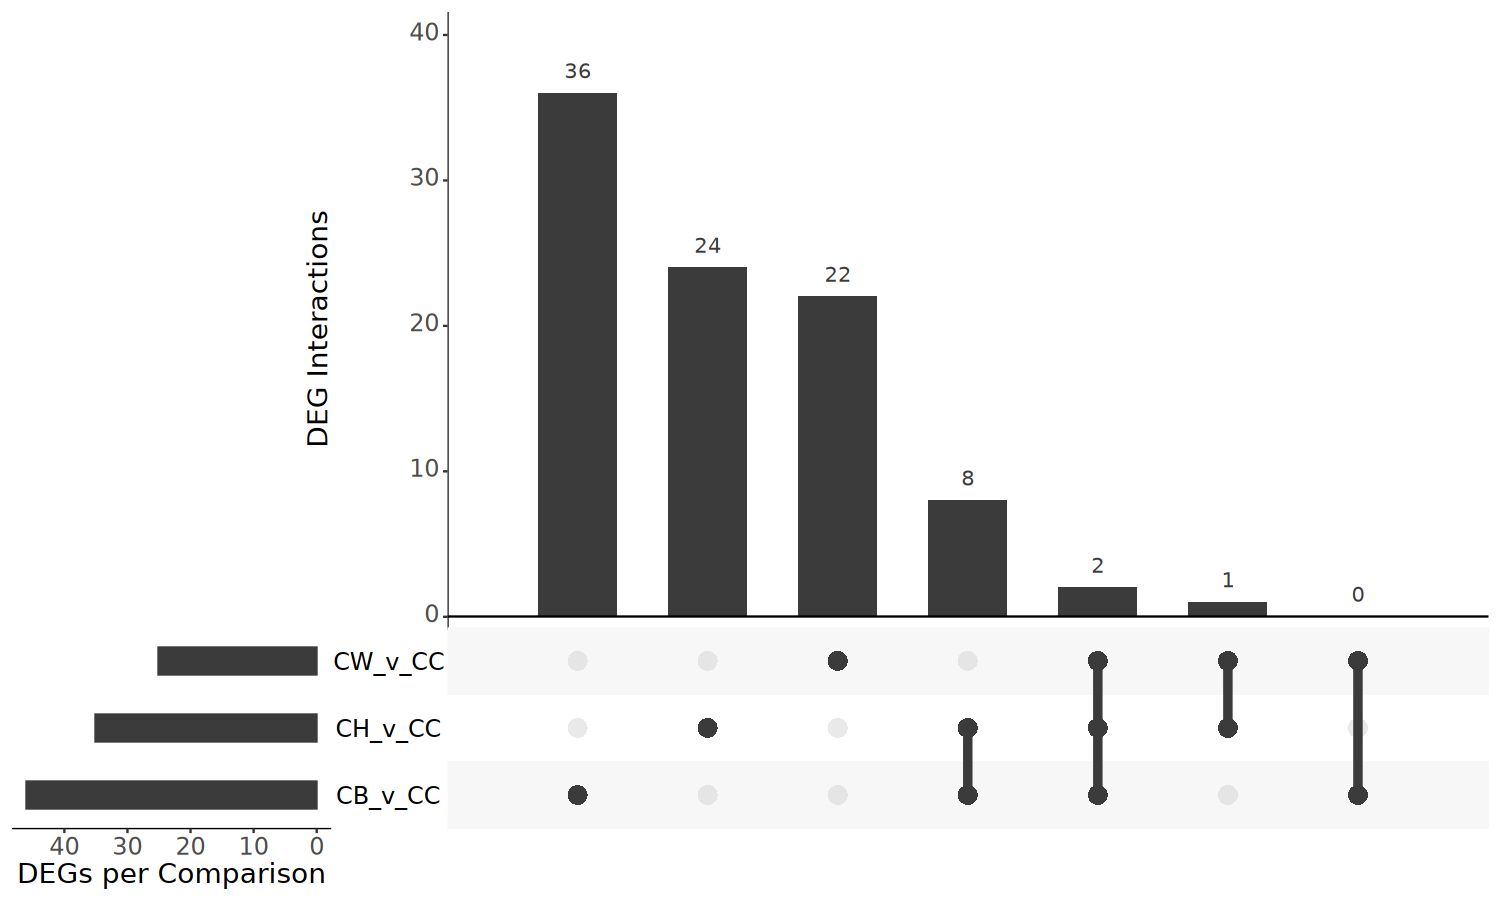

In [34]:
options(repr.plot.width=12.5, repr.plot.height=7.5)

comp2.upset <- UpSetR::upset(fromList(comp2), 
                             nsets = 6,
                             order.by='freq', 
                             point.size = 5, 
                             line.size = 2, 
                             mainbar.y.label = "DEG Interactions", 
                             sets.x.label = "DEGs per Comparison", 
                             text.scale = c(2, 2, 2, 2, 2, 2),
                             empty.intersections = 'on'
                            )

comp2.upset

The majority of DEGs are unique to that comparison - overall, there is a reduction in the number of DEGs but roughly the same pattern remains

In [35]:
# pull out the 2 shared genes across all 3 comparisons
shared_geneLate <- deg_list$cw_cc %>%
  inner_join(deg_list$ch_cc, by = "Gene") %>%
  inner_join(deg_list$cb_cc, by = "Gene") %>%
  pull(Gene) %>%
  unique()

length(shared_geneLate)
shared_geneLate

gff.file[gff.file$gene %in% shared_geneLate, ]

[1] 2

[1] "LOC111127247" "LOC144619223"

,description,gene,gene_biotype
,<chr>,<chr>,<chr>
172907,uncharacterized LOC111127247,LOC111127247,protein_coding
866058,uncharacterized LOC144619223,LOC144619223,protein_coding


### Comparison 1 and 2 together

In [36]:
# make list of dfs
comp1_2 = list(WC_v_CC = deg_list$wc_cc$Gene,
         HC_v_CC = deg_list$hc_cc$Gene,
         BC_v_CC = deg_list$bc_cc$Gene,
             CW_v_CC = deg_list$cw_cc$Gene,
         CH_v_CC = deg_list$ch_cc$Gene,
         CB_v_CC = deg_list$cb_cc$Gene)

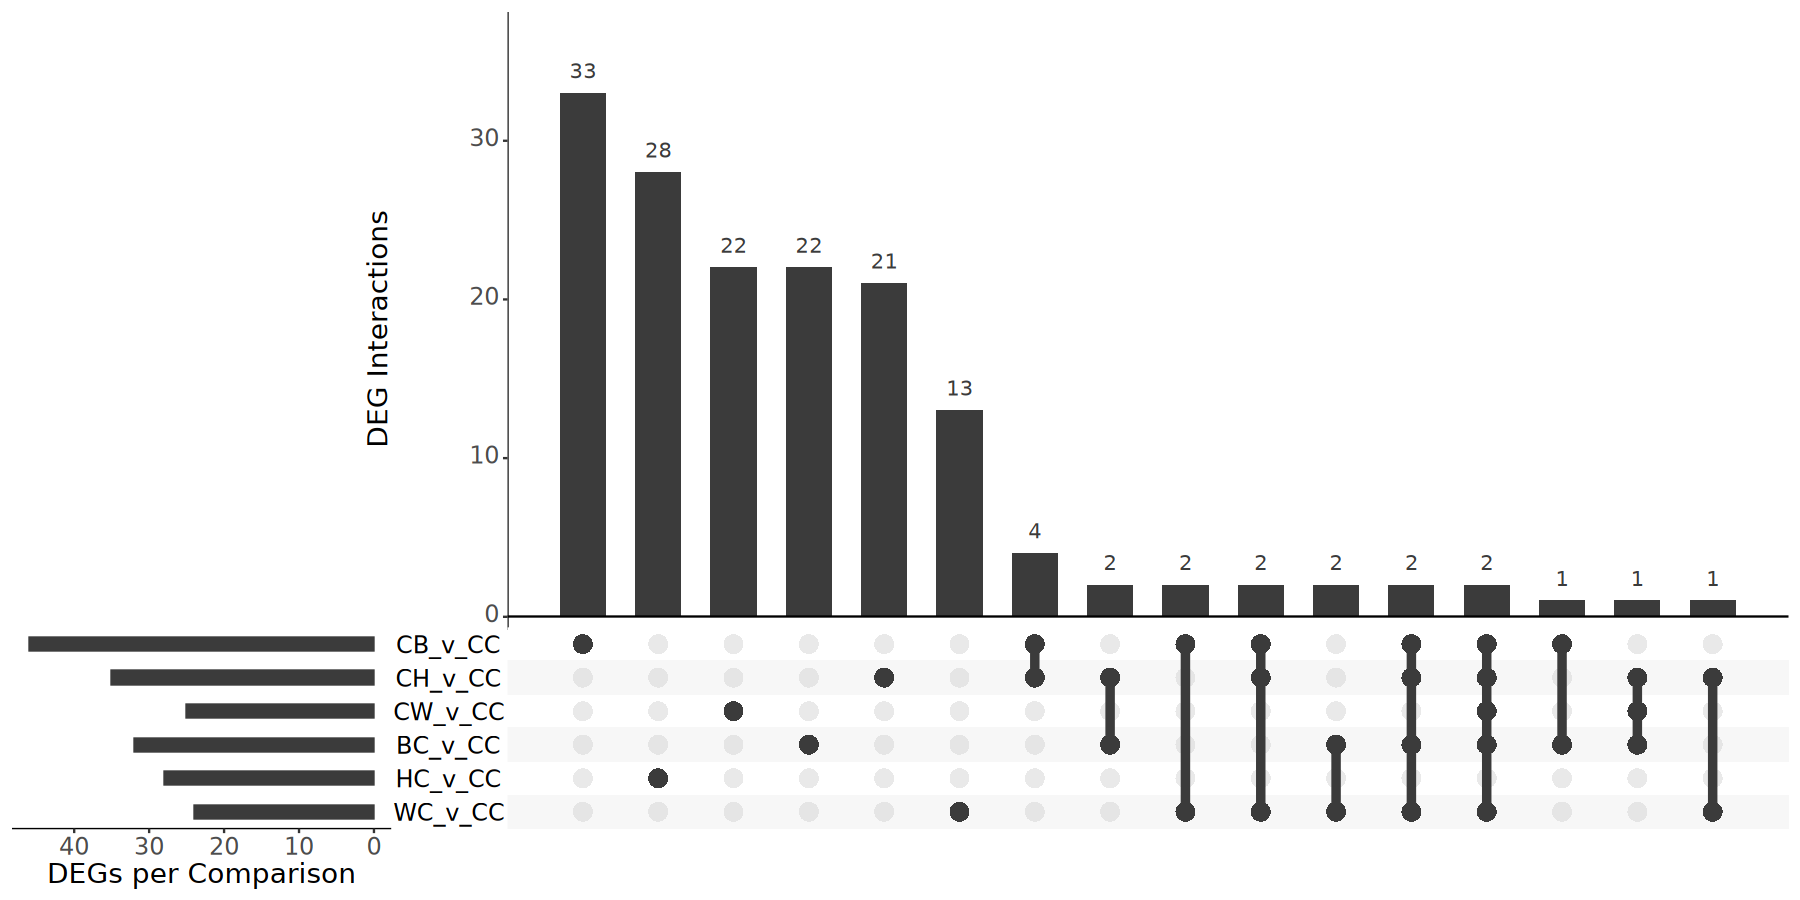

In [37]:
options(repr.plot.width=15, repr.plot.height=7.5)

comp1_2.upset <- UpSetR::upset(fromList(comp1_2), nsets = 6,, order.by='freq', point.size = 5, line.size = 2, keep.order=TRUE,
                       sets = c('WC_v_CC',
                                'HC_v_CC',
                                'BC_v_CC',
                                'CW_v_CC',
                                'CH_v_CC',
                                'CB_v_CC'),
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Comparison", 
    text.scale = c(2, 2, 2, 2, 2, 2))

comp1_2.upset

- the majority of DEGs are unique to that comparison
- no shared DEGs among all comparisons

### 3. Effect of timing of initial stress exposure

I don't think it makes sense to look at the overlap for this comparison - skipping

### 4. No stress vs. most stress

In [38]:
# make list of dfs
comp4 = list(WW_v_CC = deg_list$ww_cc$Gene,
         HH_v_CC = deg_list$hh_cc$Gene,
         BB_v_CC = deg_list$bb_cc$Gene)

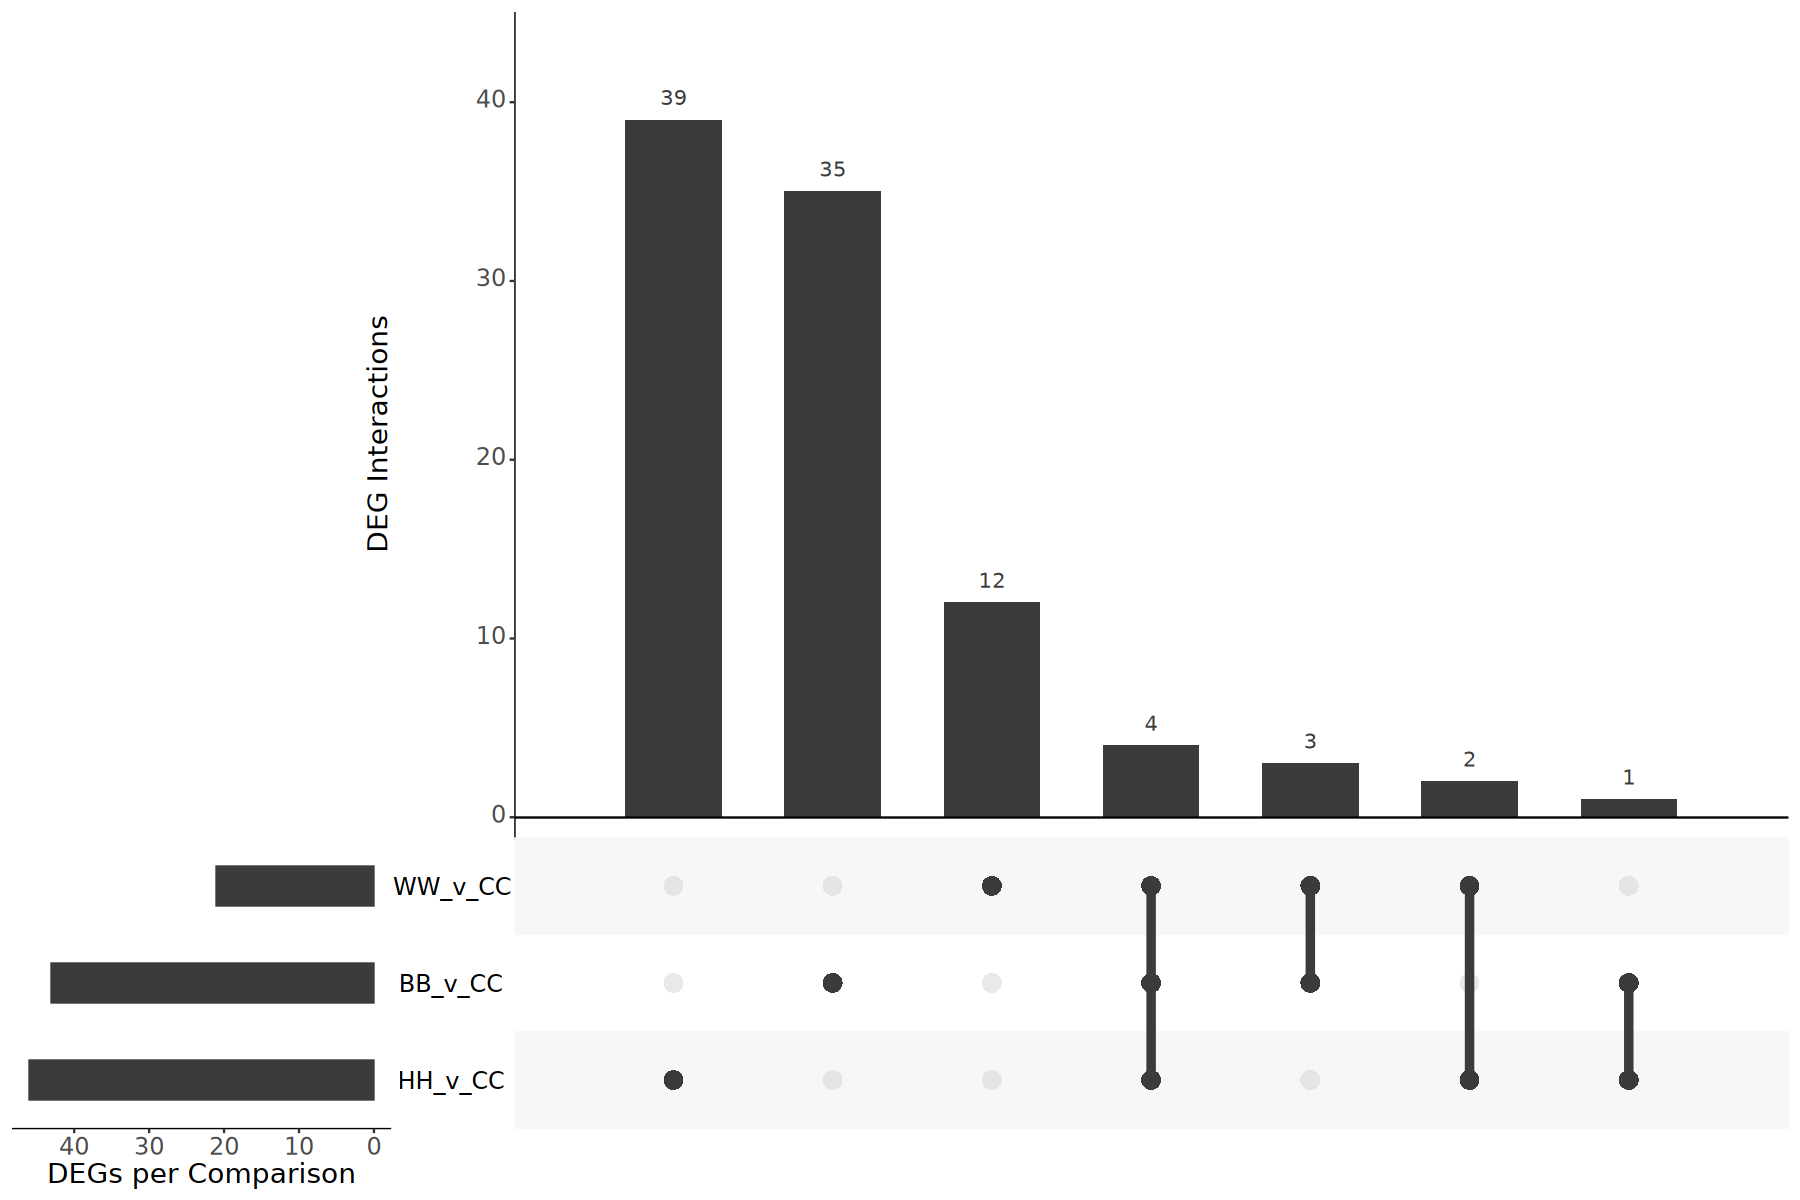

In [39]:
options(repr.plot.width=15, repr.plot.height=10)

comp4.upset <- UpSetR::upset(fromList(comp4), nsets = 6,, order.by='freq', point.size = 5, line.size = 2,
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Comparison", 
    text.scale = c(2, 2, 2, 2, 2, 2))

comp4.upset

- 4 shared between all 3 comparisons - general response to repeated exposure to the same stressor - maybe stress resilience genes??

#### pull 4 shared genes 

In [40]:
# pull out the 4 shared genes across all 3 comparisons
shared_gene2 <- deg_list$ww_cc %>%
  inner_join(deg_list$hh_cc, by = "Gene") %>%
  inner_join(deg_list$bb_cc, by = "Gene") %>%
  pull(Gene) %>%
  unique()

length(shared_gene2)
shared_gene2

[1] 4

[1] "LOC111127247" "LOC144625005" "LOC111134504" "LOC144619223"

In [41]:
gff.file[gff.file$gene %in% shared_gene2, ]

,description,gene,gene_biotype
,<chr>,<chr>,<chr>
172907,uncharacterized LOC111127247,LOC111127247,protein_coding
543419,lectin BRA-3-like,LOC144625005,protein_coding
707342,uncharacterized LOC111134504,LOC111134504,protein_coding
866058,uncharacterized LOC144619223,LOC144619223,protein_coding


- 3 are uncharacterized, but we see lectin BRA-3 show up again (saw this gene when looking at genes shared among early life stressors (HC, WC, and BC against control)
    - so maybe this reaffirms that lectin BRA-3 has constitutive expression (lasting expression or expression due to an early exposure) 

## 4. Upset plots *between* comparison groups

I'm curious if there's overlap in comparisons like CC vs. WC, CC vs. CW, and CC vs. WW - this should tell us strategies oysters use to deal with timing and repeated stressors

### Warming against control oysters

In [42]:
# make list of dfs
warm = list(WW_v_CC = deg_list$ww_cc$Gene,
         WC_v_CC = deg_list$wc_cc$Gene,
         CW_v_CC = deg_list$cw_cc$Gene)

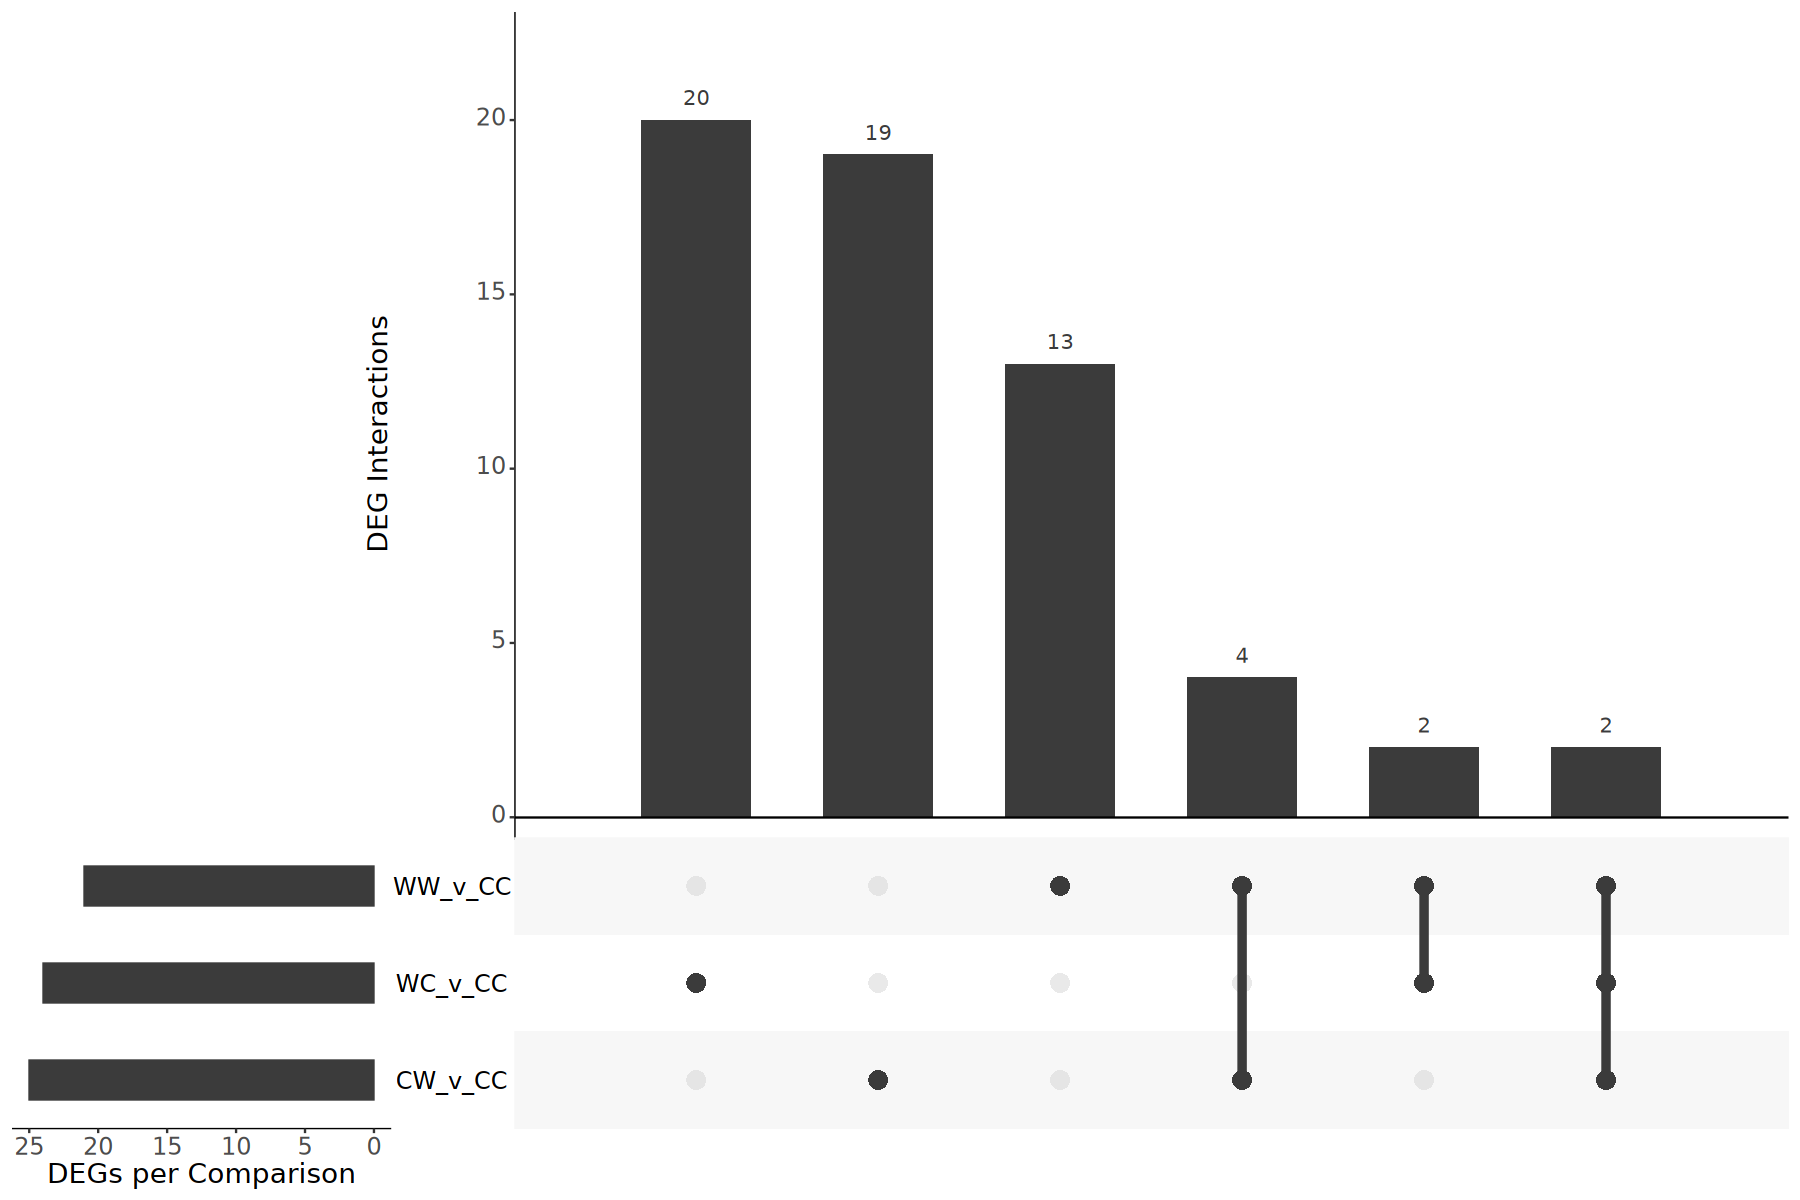

In [43]:
options(repr.plot.width=15, repr.plot.height=10)

warm.upset <- UpSetR::upset(fromList(warm), nsets = 6,, order.by='freq', point.size = 5, line.size = 2,
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Comparison", 
    text.scale = c(2, 2, 2, 2, 2, 2))

warm.upset

it's interesting that all three comparisons have roughly the same number of DEGs, but the majority are unique to that comparison - I wonder if there's functional redundancy

#### pull 2 shared genes 

In [44]:
# pull out the 2 shared genes across all 3 comparisons
shared_gene4 <- deg_list$wc_cc %>%
  inner_join(deg_list$ww_cc, by = "Gene") %>%
  inner_join(deg_list$cw_cc, by = "Gene") %>%
  pull(Gene) %>%
  unique()

length(shared_gene4)
shared_gene4

[1] 2

[1] "LOC111127247" "LOC144619223"

In [45]:
gff.file[gff.file$gene %in% shared_gene4, ]

,description,gene,gene_biotype
,<chr>,<chr>,<chr>
172907,uncharacterized LOC111127247,LOC111127247,protein_coding
866058,uncharacterized LOC144619223,LOC144619223,protein_coding


### Hypoxia against control oysters

In [46]:
# make list of dfs
hypoxia = list(HH_v_CC = deg_list$hh_cc$Gene,
         HC_v_CC = deg_list$hc_cc$Gene,
         CH_v_CC = deg_list$ch_cc$Gene)

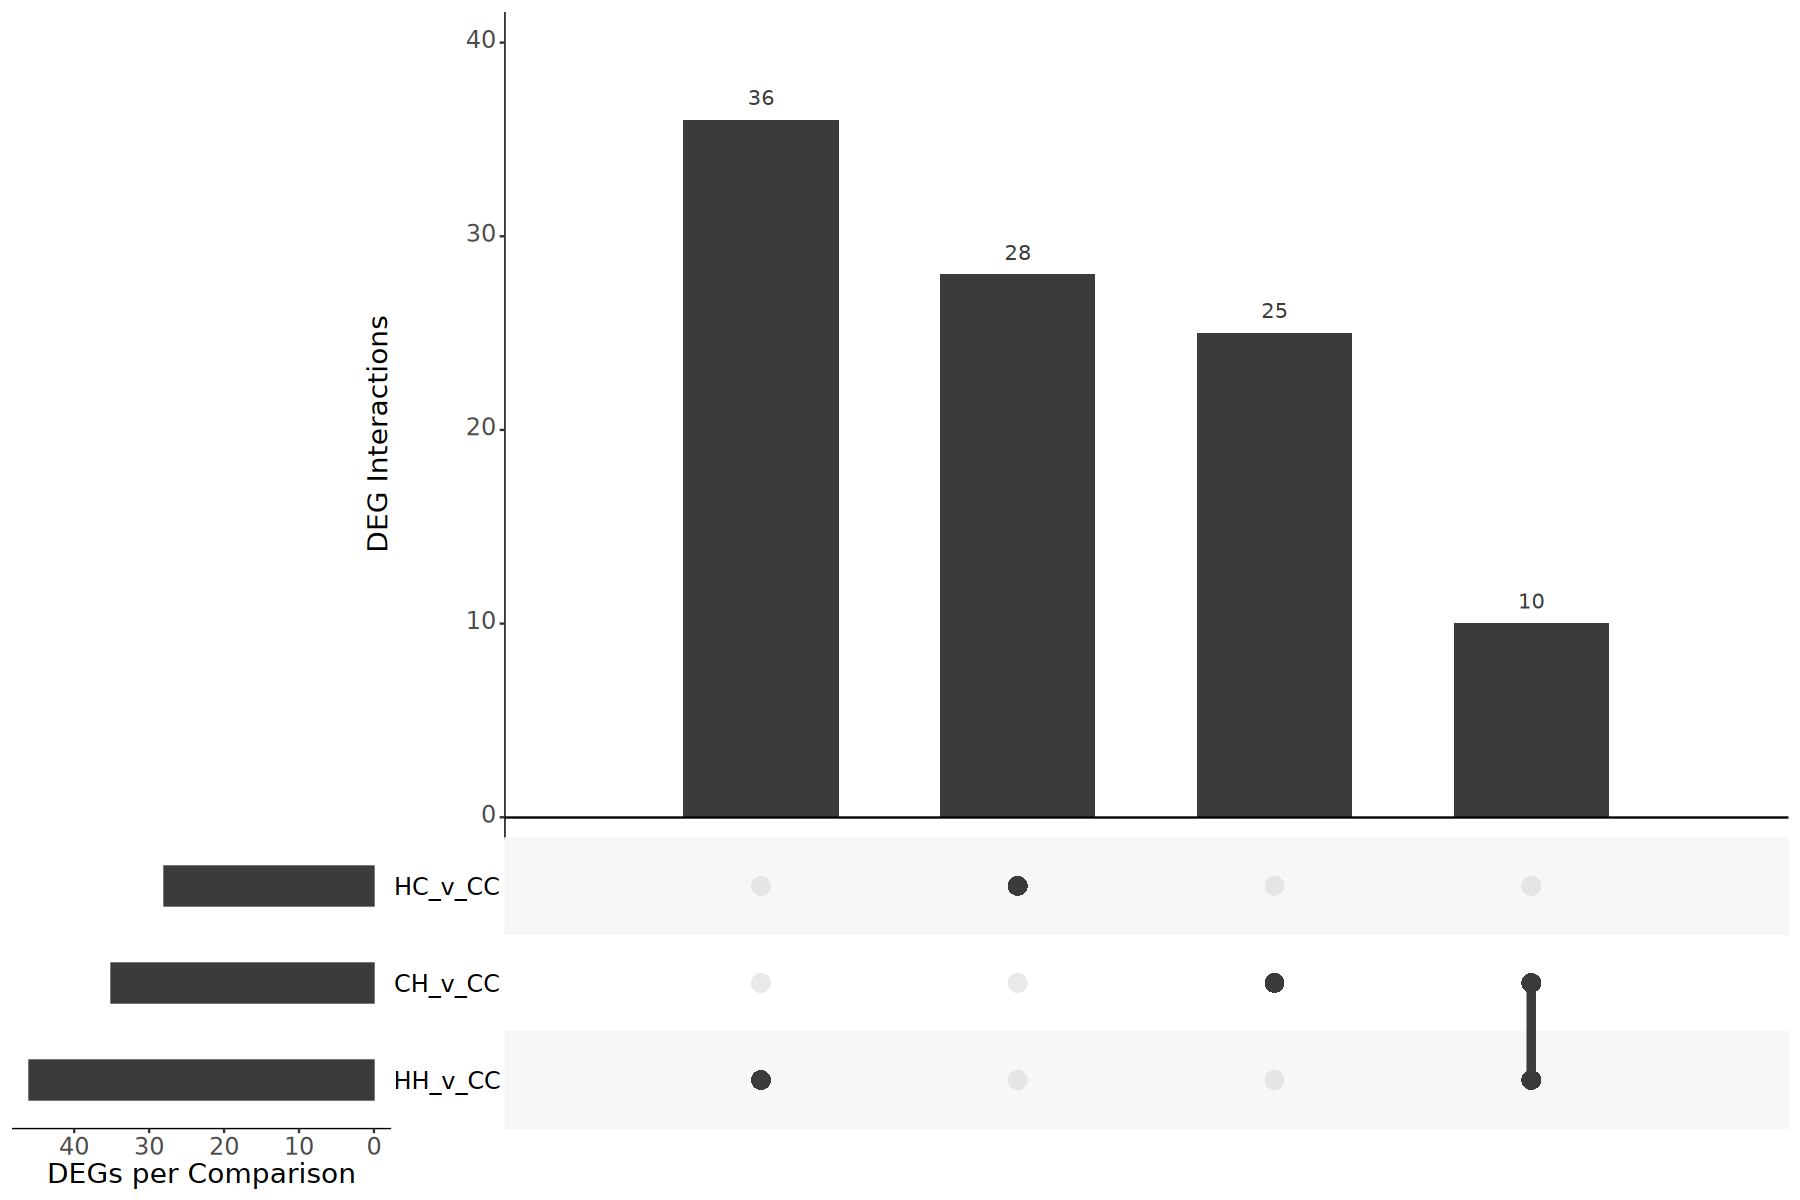

In [47]:
options(repr.plot.width=15, repr.plot.height=10)

hypoxia.upset <- UpSetR::upset(fromList(hypoxia), nsets = 6,, order.by='freq', point.size = 5, line.size = 2,
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Comparison", 
    text.scale = c(2, 2, 2, 2, 2, 2))

hypoxia.upset

don't see any shared genes in all 3 comparisons

#### Both warming and hypoxia against control oysters

In [48]:
# make list of dfs
both = list(BB_v_CC = deg_list$bb_cc$Gene,
         BC_v_CC = deg_list$bc_cc$Gene,
         CB_v_CC = deg_list$cb_cc$Gene)

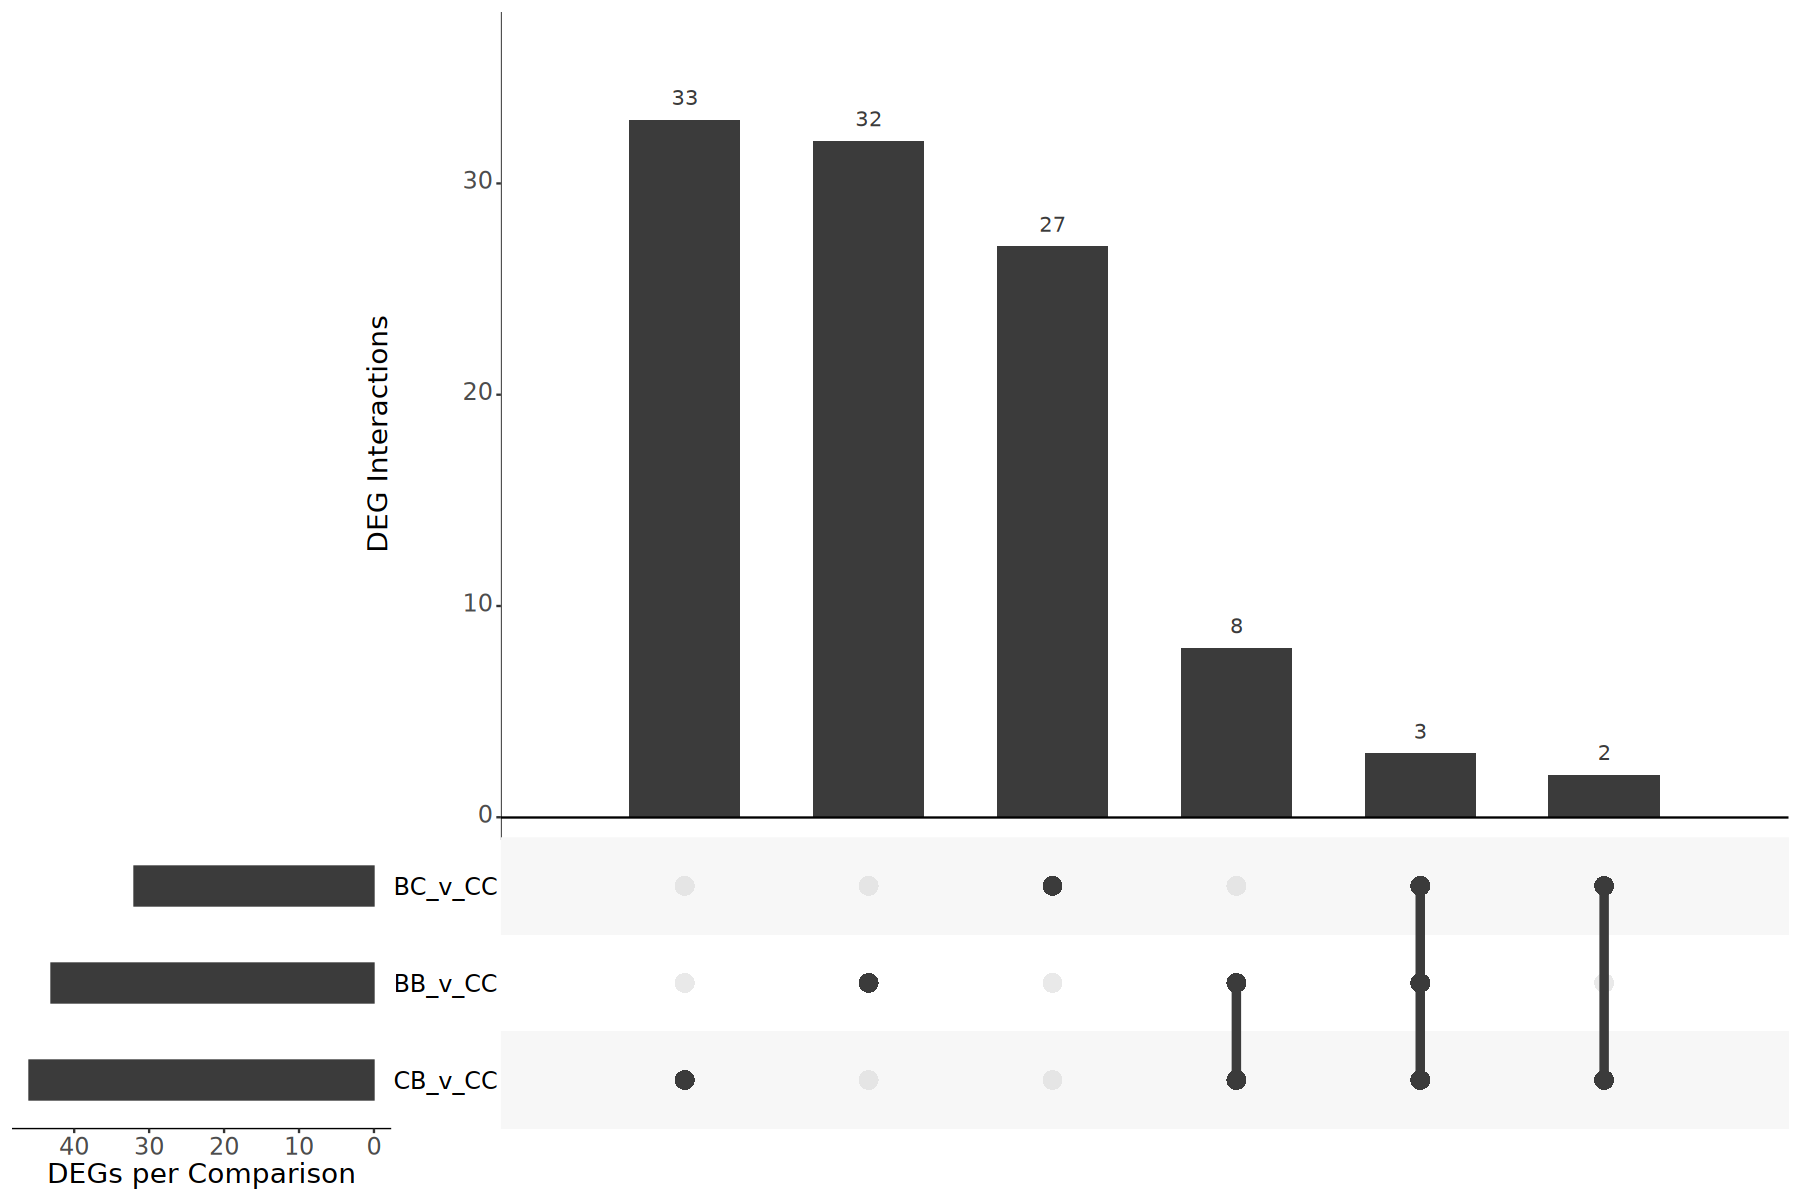

In [49]:
options(repr.plot.width=15, repr.plot.height=10)

both.upset <- UpSetR::upset(fromList(both), nsets = 6,, order.by='freq', point.size = 5, line.size = 2,
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Comparison", 
    text.scale = c(2, 2, 2, 2, 2, 2))

both.upset

#### pull 3 shared genes

In [50]:
# pull out the 3 shared genes across all 3 comparisons
shared_gene2 <- deg_list$cb_cc %>%
  inner_join(deg_list$bc_cc, by = "Gene") %>%
  inner_join(deg_list$bb_cc, by = "Gene") %>%
  pull(Gene) %>%
  unique()

length(shared_gene2)
shared_gene2

[1] 3

[1] "LOC111127247" "LOC144625005" "LOC144619223"

In [51]:
gff.file[gff.file$gene %in% shared_gene2, ]

,description,gene,gene_biotype
,<chr>,<chr>,<chr>
172907,uncharacterized LOC111127247,LOC111127247,protein_coding
543419,lectin BRA-3-like,LOC144625005,protein_coding
866058,uncharacterized LOC144619223,LOC144619223,protein_coding


saw lectin BRA-3-like when comparing double stress vs. control oysters above

## stress sets
meaning, fully factorial set of pairwise comparisons within a single stressor type and control

#### warming

In [53]:
# make list of dfs
warming = list(CW_v_CC = deg_list$cw_cc$Gene,
         WC_v_CC = deg_list$wc_cc$Gene,
         WW_v_CC = deg_list$ww_cc$Gene,
              CW_v_WC = deg_list$cw_wc$Gene,
              WW_v_CW = deg_list$ww_cw$Gene,
              WC_v_WW = deg_list$wc_ww$Gene)

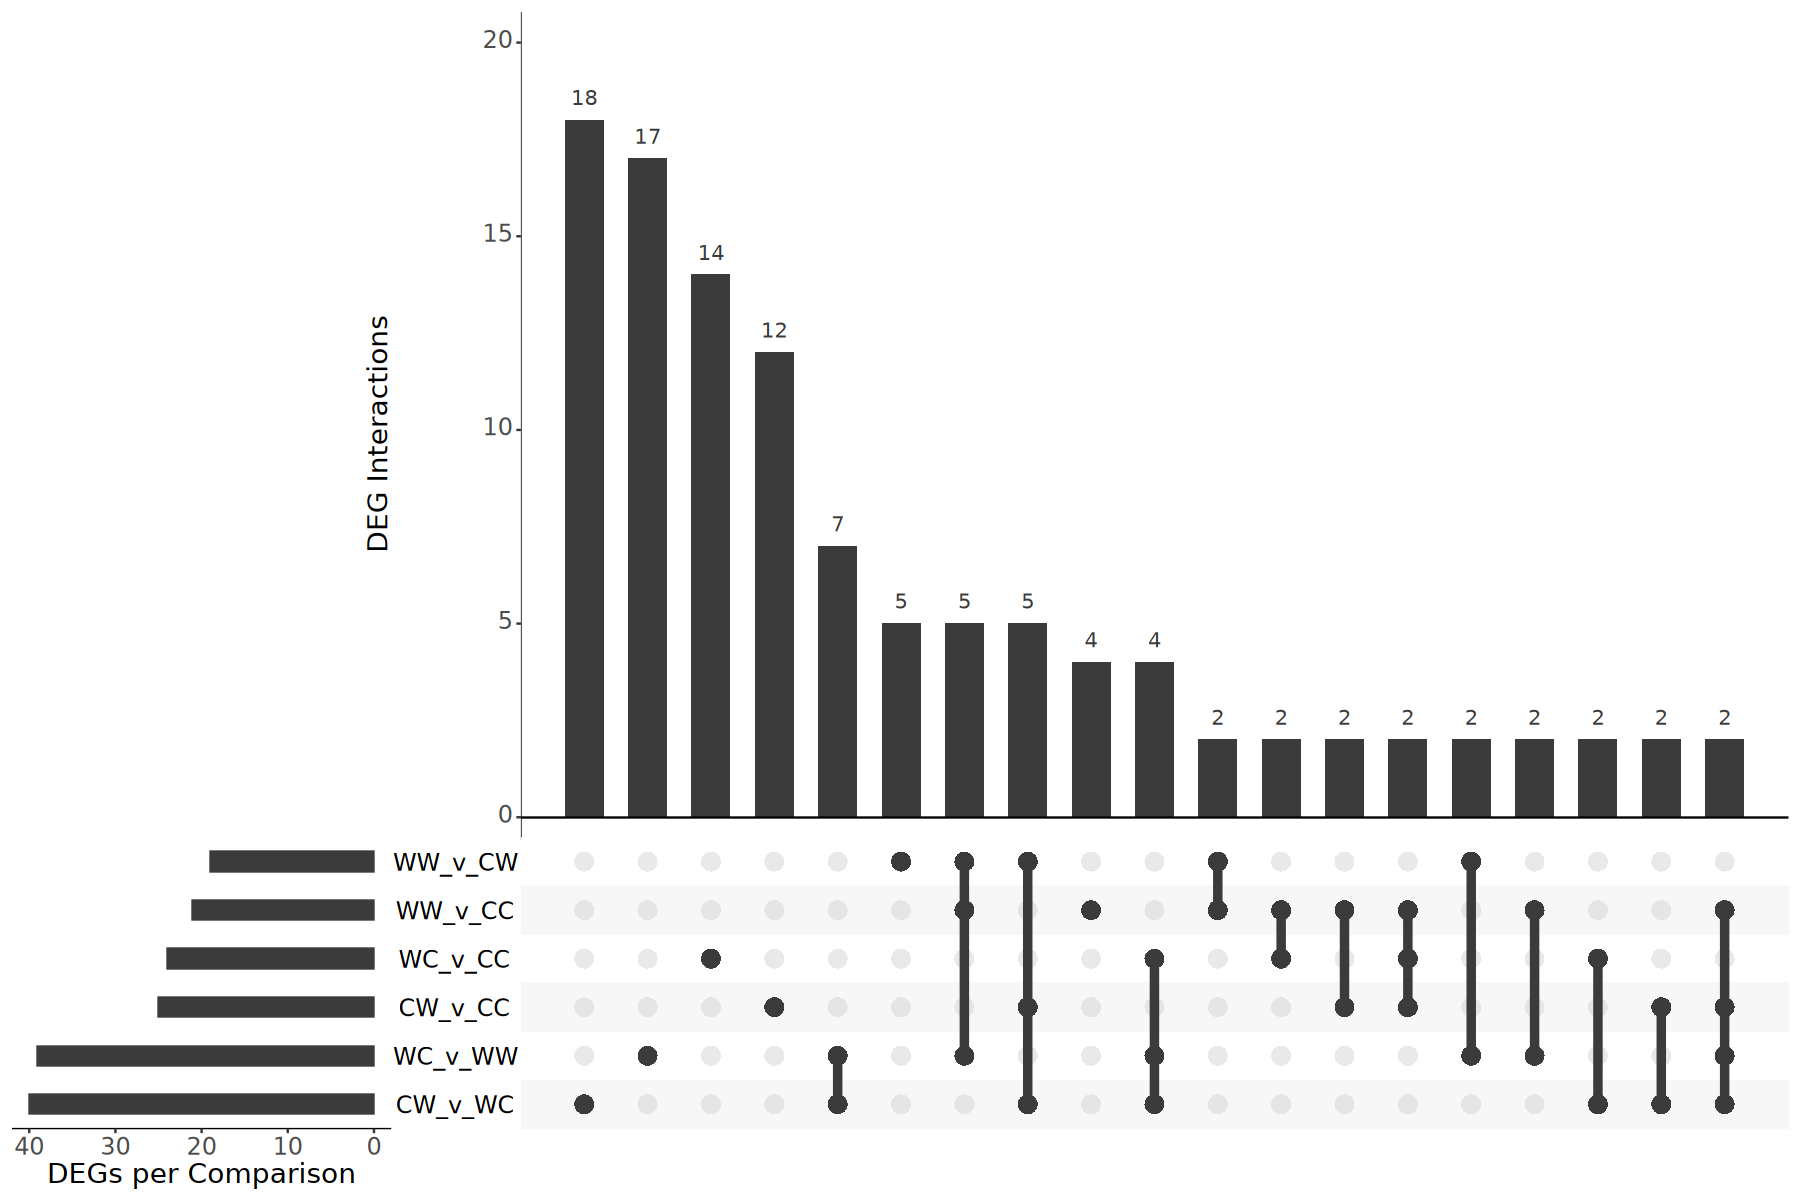

In [54]:
options(repr.plot.width=15, repr.plot.height=10)

warming.upset <- UpSetR::upset(fromList(warming), nsets = 6,, order.by='freq', point.size = 5, line.size = 2,
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Comparison", 
    text.scale = c(2, 2, 2, 2, 2, 2))

warming.upset

#### hypoxia

In [55]:
# make list of dfs
hyp = list(CH_v_CC = deg_list$ch_cc$Gene,
         HC_v_CC = deg_list$hc_cc$Gene,
         HH_v_CC = deg_list$hh_cc$Gene,
              CH_v_HC = deg_list$ch_hc$Gene,
              HH_v_CH = deg_list$hh_ch$Gene,
              HC_v_HH = deg_list$hc_hh$Gene)

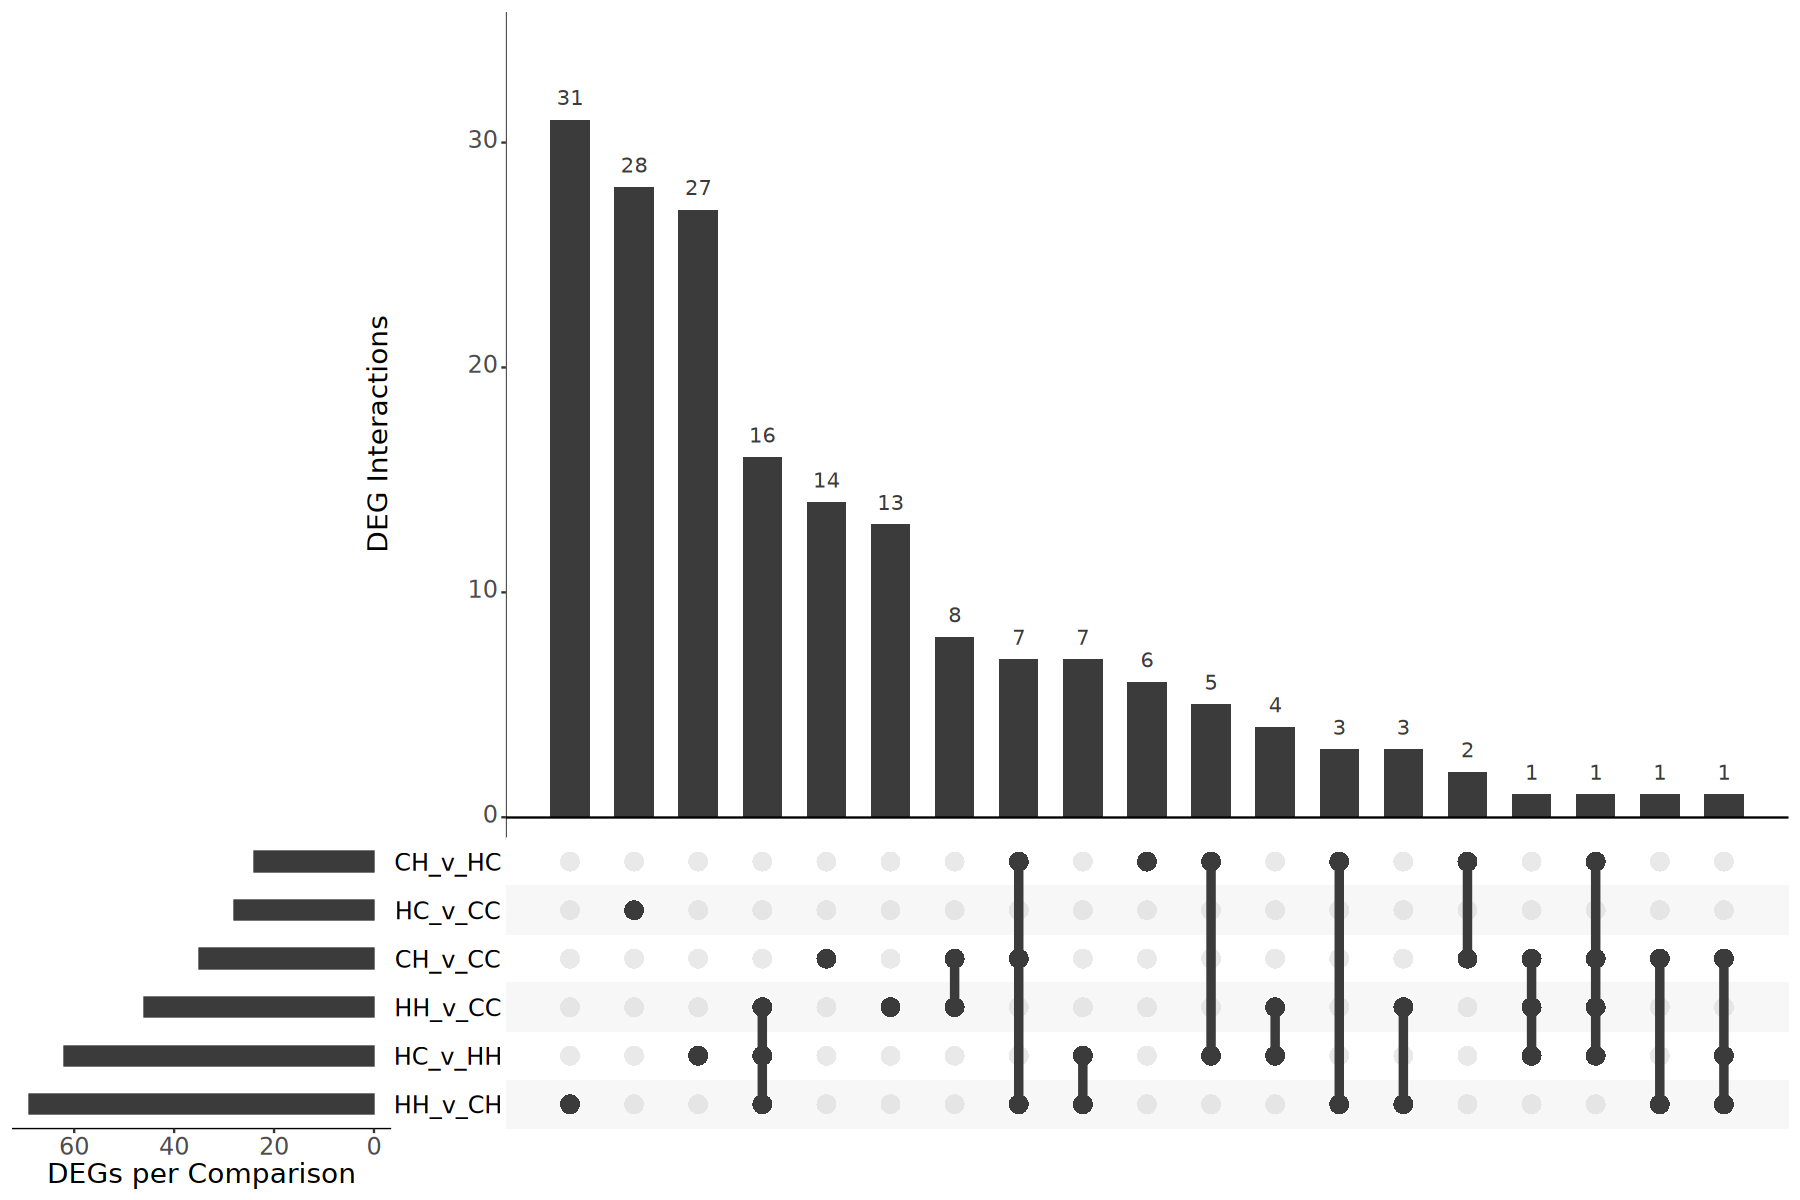

In [56]:
options(repr.plot.width=15, repr.plot.height=10)

hyp.upset <- UpSetR::upset(fromList(hyp), nsets = 6,, order.by='freq', point.size = 5, line.size = 2,
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Comparison", 
    text.scale = c(2, 2, 2, 2, 2, 2))

hyp.upset

#### both

In [63]:
# make list of dfs
both = list(CB_v_CC = deg_list$cb_cc$Gene,
         BC_v_CC = deg_list$bc_cc$Gene,
         BB_v_CC = deg_list$bb_cc$Gene,
              CB_v_BC = deg_list$cb_bc$Gene,
              BB_v_CB = deg_list$cb_bb$Gene,
              BC_v_BB = deg_list$bc_bb$Gene)

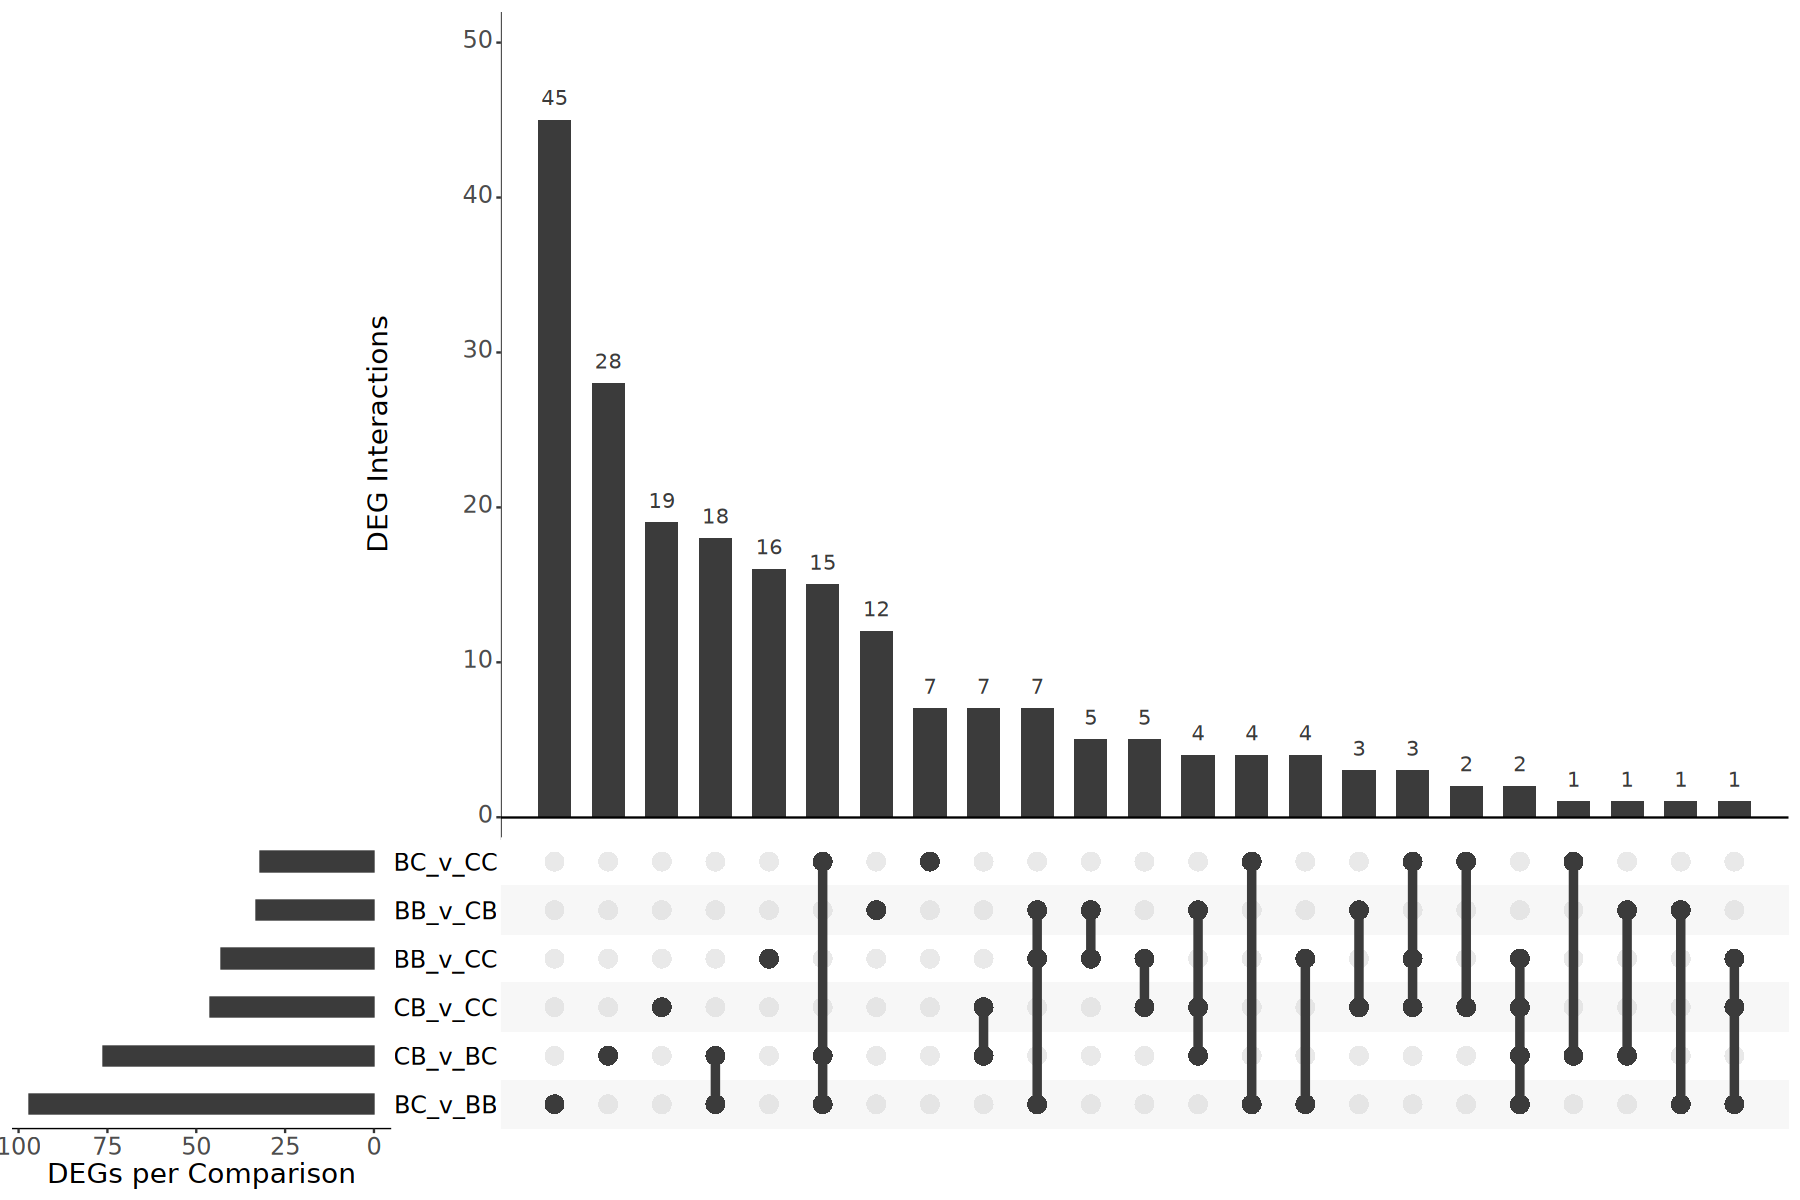

In [64]:
options(repr.plot.width=15, repr.plot.height=10)

both.upset <- UpSetR::upset(fromList(both), nsets = 6,, order.by='freq', point.size = 5, line.size = 2,
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Comparison", 
    text.scale = c(2, 2, 2, 2, 2, 2))

both.upset

woah okay - first time seeing major overlap between comparisons:
- 18 DEGs shared between CB vs. BC, and BC vs. BB (all involve the BC treatment; have a different late exposure)
- 15 DEGs shared between BC vs. CC, CB vs. BC, and BC vs. BB (same deal as above)

### comparison 1, 2, and 4 together

In [65]:
# make list of dfs
comp1_2_4 = list(WC_v_CC = deg_list$wc_cc$Gene,
               HC_v_CC = deg_list$hc_cc$Gene,
               BC_v_CC = deg_list$bc_cc$Gene,
               CW_v_CC = deg_list$cw_cc$Gene,
               CH_v_CC = deg_list$ch_cc$Gene,
               CB_v_CC = deg_list$cb_cc$Gene,
               WW_v_CC = deg_list$ww_cc$Gene,
               HH_v_CC = deg_list$hh_cc$Gene,
               BB_v_CC = deg_list$bb_cc$Gene
              )

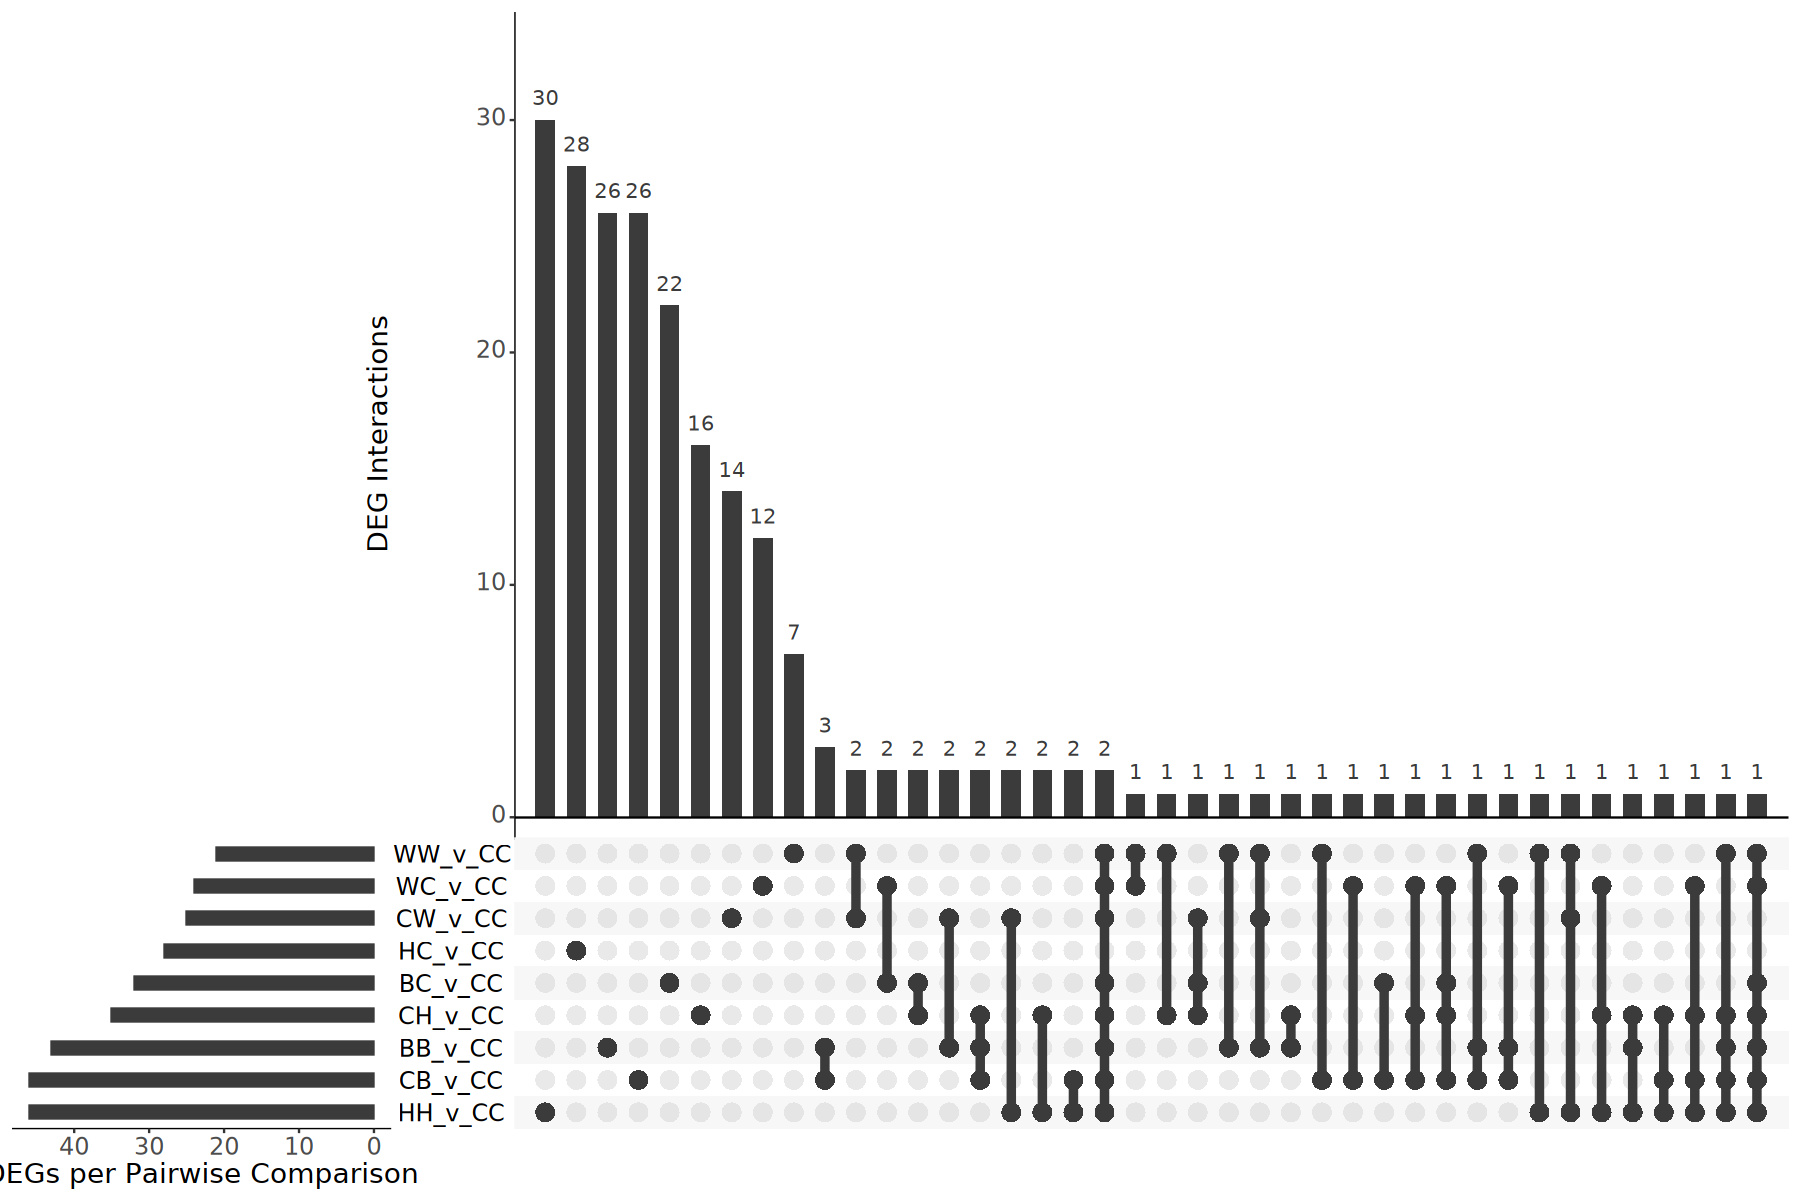

In [66]:
options(repr.plot.width=15, repr.plot.height=10)

comp1_2_4.upset <- UpSetR::upset(fromList(comp1_2_4), 
                         nsets = 9,
                         order.by='freq', 
                         point.size = 5, 
                         line.size = 2, 
                         keep.order=TRUE,
                         mainbar.y.label = "DEG Interactions", 
                         sets.x.label = "DEGs per Pairwise Comparison", 
                         text.scale = c(2, 2, 2, 2, 2, 2))

comp1_2_4.upset

there's 0 DEGs that are shared between all of these comparisons (vs. control) 

most DEGs are unique to that comparison, with minimal overlap with other stressors

## add in meta data for downstream analyses

In [57]:
metaData <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv')
head(metaData)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
3,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
4,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
5,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
6,B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA


In [66]:
shared_gene.merge <- merge(metaData, shared_expr, by = 'Sample')
head(shared_gene.merge)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,Gene,vst_expr
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC111102028,0.0000000
2,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC111127247,0.9503776
3,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC144624971,1.9007552
4,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC144621941,0.0000000
5,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC144621228,0.0000000
6,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC144624833,0.0000000


in the comparisons I used to identify these genes, I didn't use all of the samples - only those in the "stress sets" - so I need to filter my samples for those